In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql

dlq = []
nat = []
plot_df = []

q = r"""
SELECT t.reporting_date,
       t2.property_state,
       COUNT(*) AS loan_count,
       SUM(CASE WHEN t.current_loan_delinquency_status >= 1 THEN 1 ELSE 0 END) AS dlq30,
       SUM(CASE WHEN t.current_loan_delinquency_status >= 3 THEN 1 ELSE 0 END) AS dlq90,
       SUM(CASE WHEN CAST(RIGHT(TRIM(t2.origination_date), 4) AS INT) BETWEEN 2005 AND 2007 THEN 1 ELSE 0 END) AS legacy_loans
FROM fnma_monthly_mbs_loans t
JOIN fnma_static_table t2 ON t2.loan_identifier = t.loan_identifier
WHERE TRY_CAST(t.current_actual_upb AS FLOAT) > 0
  AND t.current_loan_delinquency_status IS NOT NULL 
  AND TRY_CAST(t.loan_age AS FLOAT) >= 24 AND CAST(RIGHT(TRIM(t2.origination_date), 4) AS INT) NOT BETWEEN 2005 AND 2007
GROUP BY t.reporting_date, t2.property_state
"""
dlq = read_sql(q)
dlq["report_date"] = pd.to_datetime(dlq["reporting_date"])
dlq["dlq30_rate"] = dlq["dlq30"] / dlq["loan_count"] * 100
dlq["dlq90_rate"] = dlq["dlq90"] / dlq["loan_count"] * 100

nat = dlq.groupby("report_date")[["loan_count","dlq30","dlq90"]].sum()
nat["dlq30_rate"] = nat["dlq30"] / nat["loan_count"] * 100

print(dlq.shape, dlq["property_state"].nunique())
print(nat.loc["2014-01":"2014-06", ["loan_count","dlq30_rate"]])


C:\Users\H59045\AppData\Local\Temp\1\ipykernel_38716\1476371709.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dlq = pd.read_sql(q, conn)


(15960, 9) 54
             loan_count  dlq30_rate
report_date                        
2014-01-01       341635    3.793230
2014-02-01       474733    2.847495
2014-03-01       614375    2.091394
2014-04-01       649853    1.994451
2014-05-01       644245    2.011812
2014-06-01       638157    2.043698


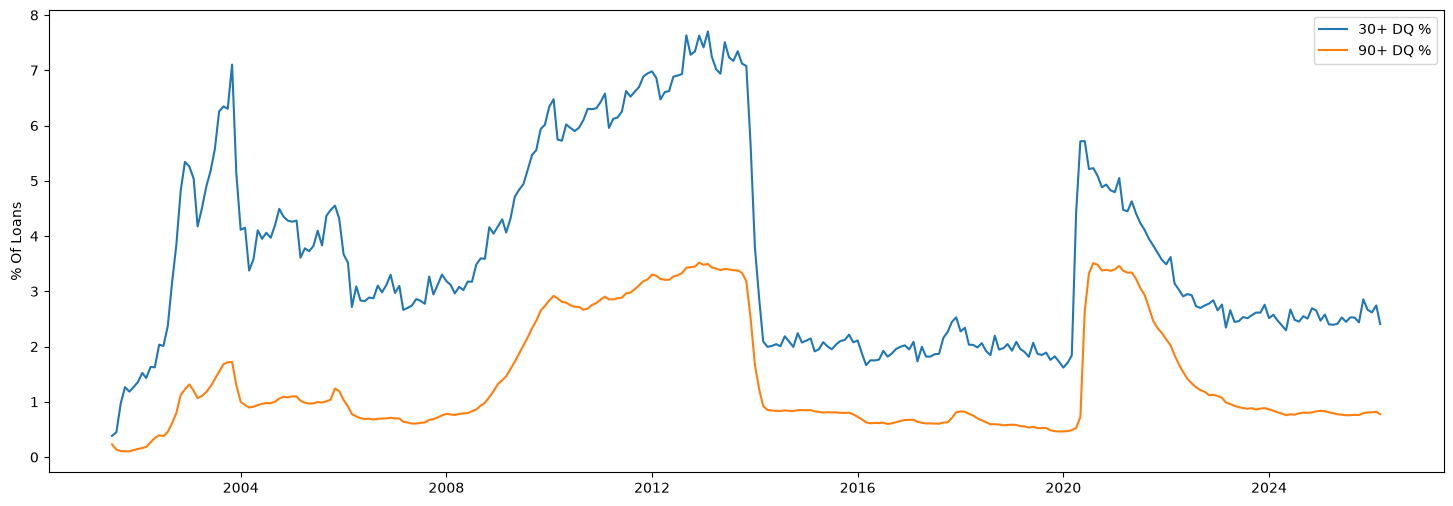

In [2]:
nat = (dlq.groupby("report_date", as_index=False)[["loan_count", "dlq30", "dlq90"]].sum())

nat['dlq30_rate'] = nat['dlq30']/nat['loan_count']*100
nat['dlq90_rate'] = nat['dlq90']/nat['loan_count']*100



fig, ax = plt.subplots(figsize=(18,6))
ax.plot(nat["report_date"], nat["dlq30_rate"], label="30+ DQ %")
ax.plot(nat["report_date"], nat["dlq90_rate"], label="90+ DQ %")
ax.set_ylabel('% Of Loans')
ax.legend()


In [3]:
econ = read_sql(""" SELECT report_date, state, unemployment_rate, hpi_index FROM economic_indicators WHERE report_date >= '2004-01-01'""")
econ['report_date'] = pd.to_datetime(econ['report_date'])

m = dlq.merge(econ, left_on=["report_date", "property_state"], right_on=["report_date", "state"], how="left")

m["ur_x_loans"] = m["unemployment_rate"] * m["loan_count"]

ur = m.groupby("report_date", as_index=False)[["ur_x_loans", "loan_count"]].sum()
ur["unemployment_rate"] = ur["ur_x_loans"]/ur["loan_count"]

plot_df = nat.merge(ur[["report_date", "unemployment_rate"]], on="report_date")

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_38716\3514727893.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  econ = pd.read_sql(""" SELECT report_date, state, unemployment_rate, hpi_index FROM economic_indicators WHERE report_date >= '2004-01-01'""", conn)


In [4]:
m = m.dropna(subset=["unemployment_rate"])

m["ur_x_loans"] = m["unemployment_rate"] * m["loan_count"]
ur = m.groupby("report_date", as_index=False)[["ur_x_loans", "loan_count"]].sum()
ur["unemployment_rate"] = ur["ur_x_loans"] / ur["loan_count"]

plot_df = nat.merge(ur[["report_date", "unemployment_rate"]], on="report_date")


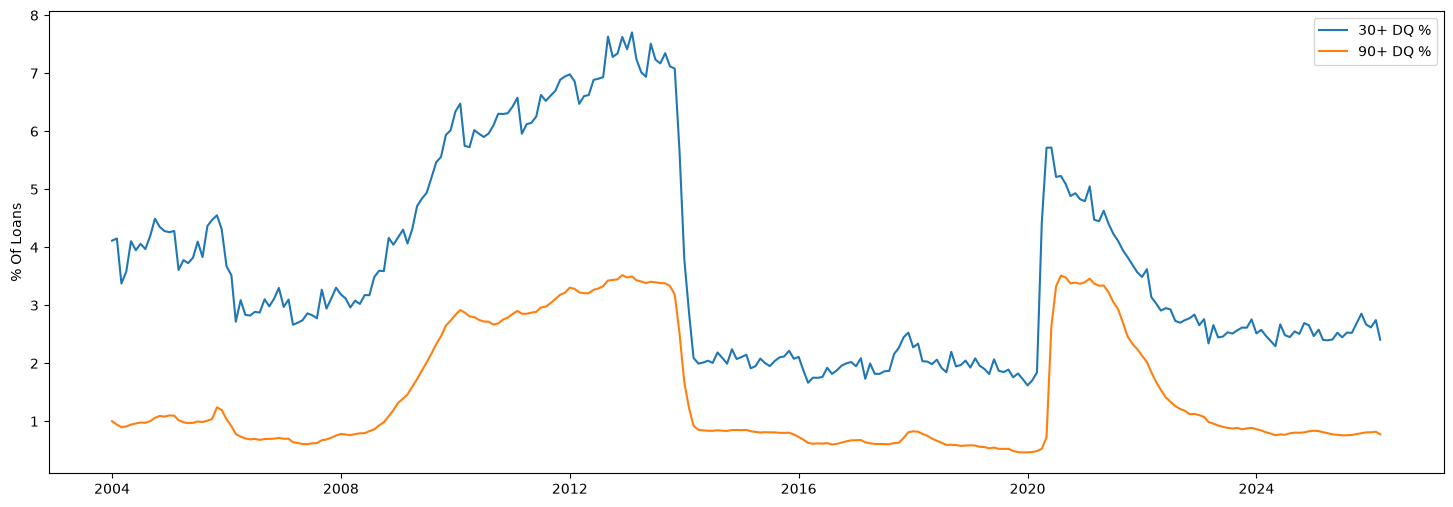

In [5]:
fig, ax = plt.subplots(figsize=(18,6))
ax.plot(plot_df["report_date"], plot_df["dlq30_rate"], label="30+ DQ %")
ax.plot(plot_df["report_date"], plot_df["dlq90_rate"], label="90+ DQ %")
ax.set_ylabel('% Of Loans')
ax.legend()

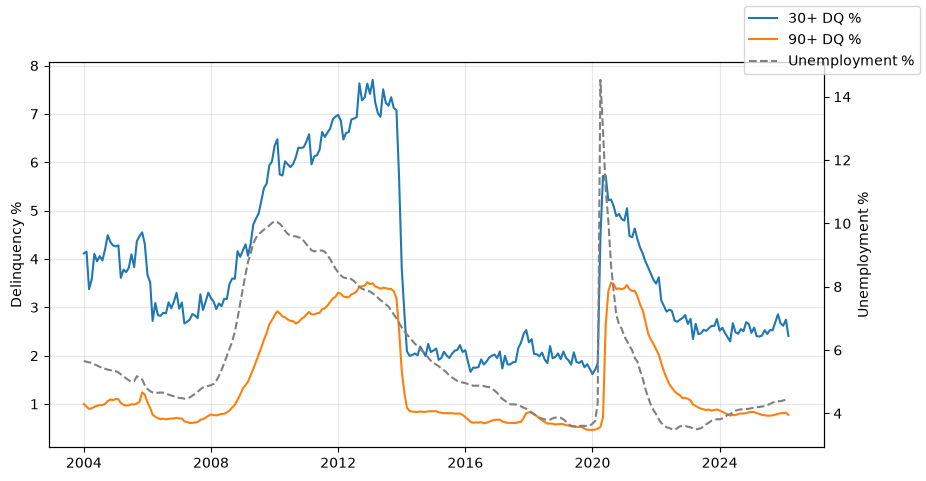

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(plot_df["report_date"], plot_df["dlq30_rate"], label="30+ DQ %")
ax1.plot(plot_df["report_date"], plot_df["dlq90_rate"], label="90+ DQ %")
ax1.set_ylabel("Delinquency %")

ax2 = ax1.twinx()
ax2.plot(plot_df["report_date"], plot_df["unemployment_rate"],
         color="gray", linestyle="--", label="Unemployment %")
ax2.set_ylabel("Unemployment %")

fig.legend(loc="upper right")
ax1.grid(alpha=0.3)
plt.show()


In [7]:
nat_ts = plot_df.sort_values("report_date").set_index("report_date")

nat_ts['dlq90_chg'] = nat_ts["dlq90_rate"].diff(12)
nat_ts["unemp_chg"] = nat_ts["unemployment_rate"].diff(12)

for lag in range(0,13):
    c = nat_ts["dlq90_chg"].corr(nat_ts['unemp_chg'].shift(lag))
    print(f'Lag {lag:2d}: {c:.3f}')

Lag  0: 0.444
Lag  1: 0.563
Lag  2: 0.689
Lag  3: 0.731
Lag  4: 0.732
Lag  5: 0.718
Lag  6: 0.695
Lag  7: 0.668
Lag  8: 0.633
Lag  9: 0.592
Lag 10: 0.541
Lag 11: 0.473
Lag 12: 0.397


In [10]:
st = m.sort_values(["property_state", "report_date"]).copy()

st["dlq90_rate"] = st["dlq90"]/st["loan_count"]*100
g = st.groupby("property_state")
st["dlq90_chg"] = st["dlq90_rate"].diff(12)
st["unemp_chg"] = st["unemployment_rate"].diff(12)

st_train = st[st["report_date"] <= "2019-12-01"]

for lag in range(0,13):
    shifted = st_train.groupby("property_state")["unemp_chg"].shift(lag)
    c=st_train["dlq90_chg"].corr(shifted)
    print(f"lag {lag:2d}: {c:.3f}")

lag  0: 0.445
lag  1: 0.473
lag  2: 0.496
lag  3: 0.500
lag  4: 0.499
lag  5: 0.493
lag  6: 0.482
lag  7: 0.468
lag  8: 0.450
lag  9: 0.428
lag 10: 0.402
lag 11: 0.374
lag 12: 0.342


In [12]:
nat_train = nat_ts.loc[:"2019-12-01"]

for lag in range(0,13):
    c= nat_train["dlq90_chg"].corr(nat_train["unemp_chg"].shift(lag))
    print(f'lag{lag:2d}: {c:.3f}')

lag 0: 0.585
lag 1: 0.609
lag 2: 0.627
lag 3: 0.638
lag 4: 0.642
lag 5: 0.639
lag 6: 0.631
lag 7: 0.617
lag 8: 0.598
lag 9: 0.573
lag10: 0.545
lag11: 0.514
lag12: 0.482


In [16]:
import statsmodels.api as sm
LAG = 5

st["unemp_chg_lag"] = st.groupby("property_state")["unemp_chg"].shift(LAG)
train = st[st["report_date"] <= "2019-12-01"].dropna(
    subset=["dlq90_chg", "unemp_chg_lag"]
)
X = sm.add_constant(train["unemp_chg_lag"])
model = sm.WLS(train["dlq90_chg"], X, weights=train["loan_count"]).fit()
print(model.summary())

                            WLS Regression Results                            
Dep. Variable:              dlq90_chg   R-squared:                       0.298
Model:                            WLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     4043.
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        12:06:51   Log-Likelihood:                -13419.
No. Observations:                9525   AIC:                         2.684e+04
Df Residuals:                    9523   BIC:                         2.686e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0694      0.008     -9.004

In [18]:
model = sm.WLS(train["dlq90_chg"], X, weights=train["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups": train["property_state"]}, use_t=True
)
print(model.summary())

                            WLS Regression Results                            
Dep. Variable:              dlq90_chg   R-squared:                       0.298
Model:                            WLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     95.59
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           3.42e-13
Time:                        12:07:34   Log-Likelihood:                -13419.
No. Observations:                9525   AIC:                         2.684e+04
Df Residuals:                    9523   BIC:                         2.686e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0694      0.011     -6.294

In [19]:
st["legacy_share"] = st["legacy_loans"]/st["loan_count"]*100
st["legacy_chg"] = st.groupby("property_state")["legacy_share"].diff(12)

In [21]:
train = st[st["report_date"] <= "2019-12-01"].dropna(
    subset=["dlq90_chg", "unemp_chg_lag", "legacy_chg"]
)

X = sm.add_constant(train[["unemp_chg_lag", "legacy_chg"]])
model = sm.WLS(train["dlq90_chg"], X, weights=train["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups": train["property_state"]}
)
print(model.summary())

                            WLS Regression Results                            
Dep. Variable:              dlq90_chg   R-squared:                       0.306
Model:                            WLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     114.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           1.53e-14
Time:                        12:07:53   Log-Likelihood:                -12945.
No. Observations:                9175   AIC:                         2.589e+04
Df Residuals:                    9173   BIC:                         2.591e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0568      0.012     -4.701

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_38716\684291874.py:6: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.WLS(train["dlq90_chg"], X, weights=train["loan_count"]).fit(
C:\Users\H59045\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  res = self.wald_test(


In [91]:
st["hpi_chg"] = st.groupby("property_state")["hpi_index"].pct_change(12, fill_method=None)* 100
st_train = st[st["report_date"] <= "2019-12-01"]

for lag in range(0,19):
    shifted = st_train.groupby("property_state")["hpi_chg"].shift(lag)
    c=st_train["dlq30_chg"].corr(shifted)
    print(f'lag{lag:2d}: {c:.3f}')

lag 0: -0.172
lag 1: -0.199
lag 2: -0.202
lag 3: -0.209
lag 4: -0.212
lag 5: -0.219
lag 6: -0.224
lag 7: -0.227
lag 8: -0.229
lag 9: -0.224
lag10: -0.224
lag11: -0.217
lag12: -0.210
lag13: -0.202
lag14: -0.192
lag15: -0.180
lag16: -0.164
lag17: -0.147
lag18: -0.128


In [92]:
LAG_HPI = 7
st["hpi_chg_lag"] = st.groupby("property_state")["hpi_chg"].shift(LAG_HPI)

train = st[st["report_date"] <= "2019-12-01"].dropna(
    subset=["dlq30_chg", "hpi_chg_lag", "legacy_chg"])

X = sm.add_constant(train[["hpi_chg_lag", "legacy_chg"]])
model_hpi = sm.WLS(train["dlq30_chg"], X, weights=train["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups": train["property_state"]})
print(model_hpi.summary())


                            WLS Regression Results                            
Dep. Variable:              dlq30_chg   R-squared:                       0.040
Model:                            WLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     48.38
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           7.03e-09
Time:                        13:16:15   Log-Likelihood:                -19822.
No. Observations:                8427   AIC:                         3.965e+04
Df Residuals:                    8425   BIC:                         3.966e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0859      0.064     -1.340      

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_33676\1495410206.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_hpi = sm.WLS(train["dlq30_chg"], X, weights=train["loan_count"]).fit(
C:\Users\H59045\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  res = self.wald_test(


In [93]:
train = st[st["report_date"] <= "2019-12-01"].dropna(
    subset=["dlq30_chg", "unemp_chg_lag", "hpi_chg_lag", "legacy_chg"])

print(train[["unemp_chg_lag", "hpi_chg_lag", "legacy_chg"]].corr())

X = sm.add_constant(train[["unemp_chg_lag", "hpi_chg_lag", "legacy_chg"]])
model_all = sm.WLS(train["dlq30_chg"], X, weights=train["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups": train["property_state"]})
print(model_all.summary())


               unemp_chg_lag  hpi_chg_lag  legacy_chg
unemp_chg_lag       1.000000    -0.421491         NaN
hpi_chg_lag        -0.421491     1.000000         NaN
legacy_chg               NaN          NaN         NaN
                            WLS Regression Results                            
Dep. Variable:              dlq30_chg   R-squared:                       0.209
Model:                            WLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     153.2
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           4.77e-22
Time:                        13:16:19   Log-Likelihood:                -19003.
No. Observations:                8427   AIC:                         3.801e+04
Df Residuals:                    8424   BIC:                         3.803e+04
Df Model:                           2                                         
Covariance Type:              cluster                                    

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_33676\1898948160.py:7: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_all = sm.WLS(train["dlq30_chg"], X, weights=train["loan_count"]).fit(
C:\Users\H59045\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  res = self.wald_test(


In [94]:
st["hpi_x_legacy"] = st["hpi_chg_lag"]* st["legacy_share"]/100

train = st[st["report_date"] <= "2019-12-01"].dropna(
    subset=["dlq30_chg", "unemp_chg_lag", "hpi_chg_lag", "legacy_chg", "hpi_x_legacy"]
)

X = sm.add_constant(train[["unemp_chg_lag", "hpi_chg_lag", "legacy_chg", "hpi_x_legacy"]])
model_int = sm.WLS(train["dlq30_chg"], X, weights=train["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups":train["property_state"]}
)
print(model_int.summary())

                            WLS Regression Results                            
Dep. Variable:              dlq30_chg   R-squared:                       0.209
Model:                            WLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     153.1
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           4.78e-22
Time:                        13:16:24   Log-Likelihood:                -19003.
No. Observations:                8427   AIC:                         3.801e+04
Df Residuals:                    8424   BIC:                         3.803e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.1482      0.045     -3.266

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_33676\2893035947.py:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model_int = sm.WLS(train["dlq30_chg"], X, weights=train["loan_count"]).fit(
C:\Users\H59045\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  res = self.wald_test(


In [96]:
X = sm.add_constant(train[["unemp_chg_lag", "hpi_chg_lag"]])
model_clean = sm.WLS(train["dlq30_chg"], X, weights=train["loan_count"]).fit(
    cov_type="cluster", cov_kwds={"groups": train["property_state"]}
)
print(model_clean.summary())

                            WLS Regression Results                            
Dep. Variable:              dlq30_chg   R-squared:                       0.209
Model:                            WLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     153.2
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           4.76e-22
Time:                        13:27:58   Log-Likelihood:                -19003.
No. Observations:                8427   AIC:                         3.801e+04
Df Residuals:                    8424   BIC:                         3.803e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.1482      0.045     -3.267

In [98]:
test = st[st["report_date"] >= "2020-01-01"].dropna(
    subset=["dlq30_chg", "unemp_chg_lag", "hpi_chg_lag"]).copy()

X_test = sm.add_constant(test[["unemp_chg_lag", "hpi_chg_lag"]], has_constant="add")
test["pred"] = model_clean.predict(X_test)

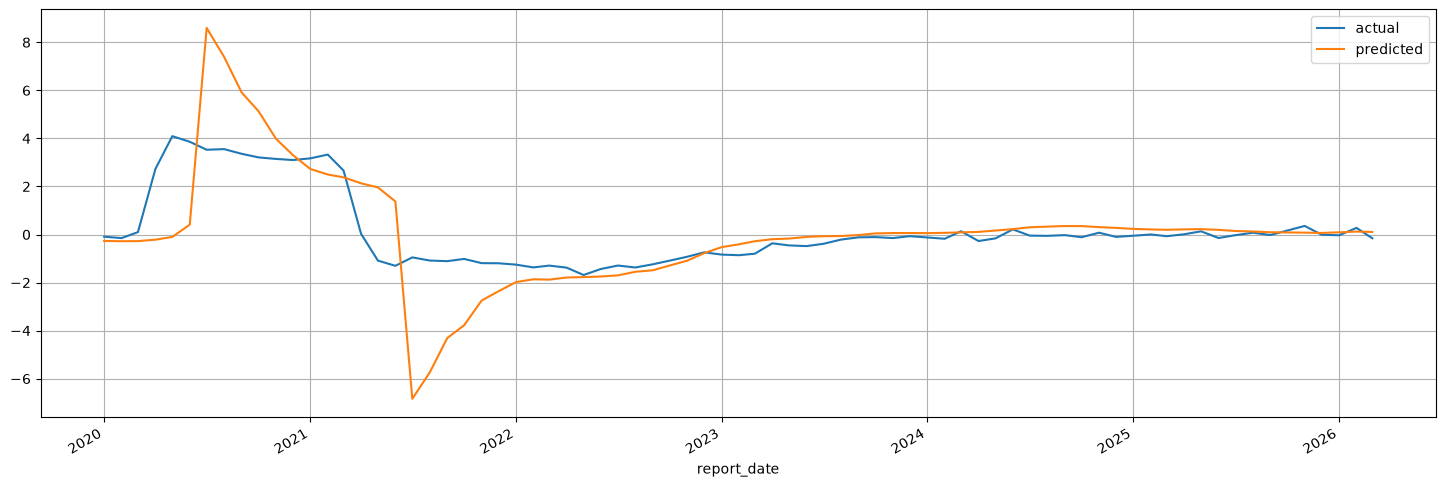

In [101]:
test["w_actual"] = test["dlq30_chg"] * test["loan_count"]
test["w_predicted"] = test["pred"] * test["loan_count"]

cmp = test.groupby("report_date")[["w_actual", "w_predicted", "loan_count"]].sum()
cmp["actual"] = cmp["w_actual"]/cmp["loan_count"]
cmp["predicted"] = cmp["w_predicted"]/cmp["loan_count"]

cmp[["actual", "predicted"]].plot(figsize=(18,6), grid=True)
plt.show()

In [104]:
import numpy as np

cmp["error"] = cmp["predicted"] - cmp["actual"]

cmp["native_error"] = 0 - cmp["actual"]

periods = {"Covid mid (2020-2021)": ("2020-01-01", "2021-06-01"), "Mid 2022 on": ("2022-07-01", None)}

for name, (start, end) in periods.items():
    p = cmp.loc[start:end]
    model_rmse = np.sqrt((p["error"] **2).mean())
    naive_rmse = np.sqrt((p["native_error"] **2).mean())
    print(f'{name}: model RMSE {model_rmse:.3f},naive RMSE{naive_rmse:.3f}')

Covid mid (2020-2021): model RMSE 2.490,naive RMSE2.753
Mid 2022 on: model RMSE 0.267,naive RMSE0.502


In [105]:
for name, (start, end) in {"H2 2022": ("2022-07-01", "2022-12-01"), "2023 On": ("2023-01-01", None)}.items():
    p = cmp.loc[start:end]
    print(f"{name}: model {np.sqrt((p["error"]**2).mean()):.3f}, "
    f"naive {np.sqrt((p["native_error"]**2).mean()):.3f}")

H2 2022: model 0.234, naive 1.131
2023 On: model 0.272, naive 0.300
